# MIMIC OOD — Deep Ensemble (5 members)

Loads the 5-member deep ensemble from `mimic_deep_ensemble/` and runs the same OOD evaluation as the Low-Rank Gaussian multi-seed notebook.

- ID: MIMIC ICU test set
- OOD: Newborn admissions
- Metrics: `MI`, `EU_var`, `sum_Ck`, `C1`, `neg_MSP`

For the ensemble, uncertainty comes from disagreement across members (one deterministic forward pass per member) rather than MC sampling.

In [1]:
import pandas as pd
from pathlib import Path

results_df = pd.read_csv(Path('results_csv') / 'mimic_deep_ensemble_ood.csv')
display(results_df)

,metric,auroc,mean_id,mean_ood,ood_to_id_ratio
0,sum_Ck,0.753190,0.018824,0.043421,2.306675
1,MI,0.752328,0.019011,0.044090,2.319256
2,EU_var,0.750244,0.012375,0.033606,2.715689
3,neg_MSP,0.700865,0.138185,0.231713,1.676827
4,C1,0.556662,0.012638,0.017042,1.348455


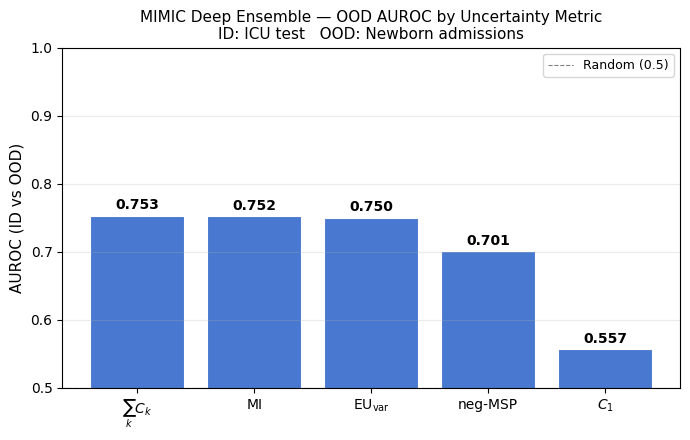

Saved: figs/fig_auroc_bar_deep_ensemble_mimic.png


In [2]:
# AUROC bar chart
import matplotlib.pyplot as plt
import numpy as np

ordered = results_df.sort_values('auroc', ascending=False)
metrics_ordered = ordered['metric'].tolist()
auroc_vals      = ordered['auroc'].tolist()

lbl_map = {
    'MI': 'MI',
    'EU_var': r'EU$_{\rm var}$',
    'sum_Ck': r'$\sum_k C_k$',
    'C1': r'$C_1$',
    'neg_MSP': 'neg-MSP'
}
xlabels = [lbl_map[m] for m in metrics_ordered]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(xlabels, auroc_vals, color='#4878d0', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, auroc_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylabel('AUROC (ID vs OOD)', fontsize=11)
ax.set_title('MIMIC Deep Ensemble — OOD AUROC by Uncertainty Metric\n'
             'ID: ICU test   OOD: Newborn admissions', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', label='Random (0.5)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

out_bar = 'figs/fig_auroc_bar_deep_ensemble_mimic.png'
fig.savefig(out_bar, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out_bar)